In [10]:
# Importing Dependencies
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Reading and loading data 
bank = pd.read_csv('loan_data.csv')
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Data Preprocessing

In [12]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [13]:
bank.shape

(11162, 17)

In [14]:
bank.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [15]:
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [16]:
bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [17]:
features = ['age','job', 'default','balance','housing','loan', 'campaign', 'duration', 'marital','previous']
bank_df = bank[features].copy()
bank_df

,age,job,default,balance,housing,loan,campaign,duration,marital,previous
0,59,admin.,no,2343,yes,no,1,1042,married,0
1,56,admin.,no,45,no,no,1,1467,married,0
2,41,technician,no,1270,yes,no,1,1389,married,0
3,55,services,no,2476,yes,no,1,579,married,0
4,54,admin.,no,184,no,no,2,673,married,0
...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,no,1,yes,no,1,257,single,0
11158,39,services,no,733,no,no,4,83,married,0
11159,32,technician,no,29,no,no,2,156,single,0
11160,43,technician,no,0,no,yes,2,9,married,5


### Label Encoding

In [18]:
bank_df['default'] = (bank_df['default'] == 'yes').astype(int)
bank_df['housing'] = (bank_df['housing'] == 'yes').astype(int)
bank_df['loan'] = (bank_df['loan'] == 'yes').astype(int)

In [19]:
bank_df.head()

,age,job,default,balance,housing,loan,campaign,duration,marital,previous
0,59,admin.,0,2343,1,0,1,1042,married,0
1,56,admin.,0,45,0,0,1,1467,married,0
2,41,technician,0,1270,1,0,1,1389,married,0
3,55,services,0,2476,1,0,1,579,married,0
4,54,admin.,0,184,0,0,2,673,married,0


In [20]:
from sklearn.preprocessing import LabelEncoder
job_encoder = LabelEncoder()
marital_encoder = LabelEncoder()

bank_df['job'] = job_encoder.fit_transform(bank_df['job'])
bank_df['marital'] = marital_encoder.fit_transform(bank_df['marital'])

In [21]:
bank_df.head()

,age,job,default,balance,housing,loan,campaign,duration,marital,previous
0,59,0,0,2343,1,0,1,1042,1,0
1,56,0,0,45,0,0,1,1467,1,0
2,41,9,0,1270,1,0,1,1389,1,0
3,55,7,0,2476,1,0,1,579,1,0
4,54,0,0,184,0,0,2,673,1,0


### Standardization

In [22]:
scaler = StandardScaler()
bank_scaled =  scaler.fit_transform(bank_df)
bank_scaled

array([[ 1.49150488, -1.39160402, -0.12361659, ...,  1.93022589,
        -0.31867191, -0.36325984],
       [ 1.23967567, -1.39160402, -0.12361659, ...,  3.15461161,
        -0.31867191, -0.36325984],
       [-0.0194704 ,  1.39910458, -0.12361659, ...,  2.92990082,
        -0.31867191, -0.36325984],
       ...,
       [-0.77495804,  1.39910458, -0.12361659, ..., -0.62225823,
         1.27998692, -0.36325984],
       [ 0.14841574,  1.39910458, -0.12361659, ..., -1.04575164,
        -0.31867191,  1.81833188],
       [-0.6070719 ,  1.39910458, -0.12361659, ...,  0.73753015,
        -0.31867191, -0.36325984]])

### Choosing the optimal K value

In [23]:
wcss = []
for i in range(2,10):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(bank_scaled)
    wcss.append(kmeans.inertia_)

c:\Users\OLAMILEKAN\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\OLAMILEKAN\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\OLAMILEKAN\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\OLAMILEKAN\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\OLAMILEKAN\anaconda3\lib\si

In [24]:
wcss

[99767.24534988539,
 89863.32762381935,
 79299.89213453053,
 72087.72964206556,
 67154.68616006114,
 62634.712956086594,
 57955.46979547479,
 54531.94619359911]

Text(0, 0.5, 'WCSS')

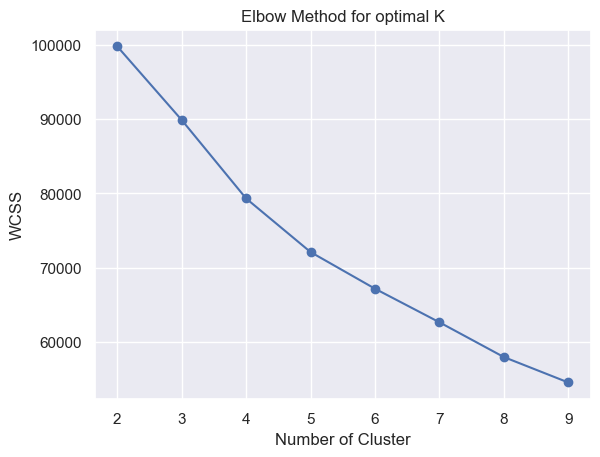

In [25]:
# Elbow Curve
sns.set_theme()
plt.plot(range(2,10),wcss, marker='o')
plt.title('Elbow Method for optimal K')
plt.xlabel('Number of Cluster')
plt.ylabel('WCSS')

### Model Training

In [26]:
kmeans = KMeans(n_clusters=4,init='k-means++',random_state=42)
bank_df['cluster'] = kmeans.fit_predict(bank_scaled)
bank_df.head()

c:\Users\OLAMILEKAN\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,age,job,default,balance,housing,loan,campaign,duration,marital,previous,cluster
0,59,0,0,2343,1,0,1,1042,1,0,1
1,56,0,0,45,0,0,1,1467,1,0,1
2,41,9,0,1270,1,0,1,1389,1,0,2
3,55,7,0,2476,1,0,1,579,1,0,1
4,54,0,0,184,0,0,2,673,1,0,1


### Cluster Group by mean 


In [27]:
cluster_summary = bank_df.groupby(bank_df['cluster']).mean()

In [28]:
cluster_summary

,age,job,default,balance,housing,loan,campaign,duration,marital,previous
cluster,,,,,,,,,,
0,40.265335,3.929387,0.0,831.208987,0.579173,1.000000,2.728245,372.678317,1.102710,0.724679
1,51.118004,4.417211,0.0,2123.093517,0.317631,0.000233,2.618237,368.125466,0.764925,0.784981
2,33.529977,4.698529,0.0,1282.569759,0.569382,0.000000,2.339932,375.808258,1.578431,0.920249
3,40.130952,4.303571,1.0,-61.803571,0.517857,0.339286,3.190476,344.589286,1.125000,0.178571


### PCA 

In [29]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(bank_scaled)
bank_df['PCA1'], bank_df['PCA2'] = pca_data[:,0], pca_data[:,1]

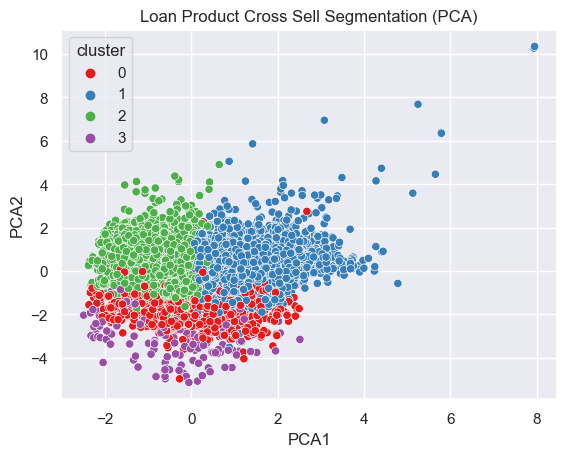

In [30]:
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=bank_df, palette='Set1')
plt.title('Loan Product Cross Sell Segmentation (PCA)')
plt.show()

In [31]:
cluster_summary

,age,job,default,balance,housing,loan,campaign,duration,marital,previous
cluster,,,,,,,,,,
0,40.265335,3.929387,0.0,831.208987,0.579173,1.000000,2.728245,372.678317,1.102710,0.724679
1,51.118004,4.417211,0.0,2123.093517,0.317631,0.000233,2.618237,368.125466,0.764925,0.784981
2,33.529977,4.698529,0.0,1282.569759,0.569382,0.000000,2.339932,375.808258,1.578431,0.920249
3,40.130952,4.303571,1.0,-61.803571,0.517857,0.339286,3.190476,344.589286,1.125000,0.178571


### Saving Model

In [32]:
import pickle
pickle.dump(kmeans,open('kmeans.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

encoders = {
    'job': job_encoder,
    'marital': marital_encoder
}
pickle.dump(encoders, open('encoders.pkl', 'wb'))